In [ ]:
from pathlib import Path
import torch
from rfdetr import RFDETRMedium
from rfdetr.config import RFDETRMediumConfig, TrainConfig
from rfdetr.training import RFDETRModelModule, RFDETRDataModule, build_trainer
import supervision as sv
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
project_dir = Path.cwd().parent
dataset_dir = str(project_dir / 'data' / 'ChessmanDetection.v5.coco')
annotation_dir = dataset_dir + '/test/_annotations.coco.json'
output_dir = str(project_dir / 'models' / 'rfdetr_medium_v2' / 'eval')
model = RFDETRMedium(pretrain_weights=str(project_dir / 'models' / 'rfdetr_medium_v2' / 'checkpoint_best_total.pth'), num_classes=12)

[2026-08-15 11:19:28] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-15 11:19:28] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-15 11:19:28] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


In [12]:
model_config = RFDETRMediumConfig(num_classes=12)
train_config = TrainConfig(dataset_dir=dataset_dir, output_dir=output_dir)
module = RFDETRModelModule(model_config, train_config)
datamodule = RFDETRDataModule(model_config, train_config)
trainer = build_trainer(train_config, model_config)

ckpt_path = project_dir / 'models' / 'rfdetr_medium_v2' / 'checkpoint_best_total.pth'
checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
if 'state_dict' in checkpoint:
    module.load_state_dict(checkpoint['state_dict'])
elif 'model_state_dict' in checkpoint:
    module.load_state_dict(checkpoint['model_state_dict'])
else:
    module.load_state_dict(checkpoint)

trainer.test(module, datamodule);

[2026-08-15 11:19:28] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-15 11:19:28] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-08-15 11:19:29] [INFO] rf-detr - File rf-detr-medium.pth already exists with correct MD5 hash.


[2026-08-15 11:19:30] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 12. The detection head will be re-initialized to 12 classes.
[2026-08-15 11:19:31] [WARNING] rf-detr - TensorBoard logging disabled: Neither `tensorboard` nor `tensorboardX` is available. Try `pip install`ing either.
Requirement 'tensorboardX' not met. HINT: Try running `pip install -U 'tensorboardX'`
Requirement 'tensorboard' not met. HINT: Try running `pip install -U 'tensorboard'`. Install with: pip install tensorboard
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[2026-08-15 11:19:31] [INFO] rf-detr - Building Roboflow test dataset with square resize at resolution 576
[2026-08-15 11:19:31] [INFO] rf-detr - Using multi-scale training with square resize and scales: [736]


[2026-08-15 11:19:31] [WARNING] rf-detr - Failed to initialize Resize with params {'height': 576, 'width': 576}: Unknown Albumentations transform: 'Resize'. Skipping.


[2026-08-15 11:19:31] [INFO] rf-detr - Built 0 Albumentations transforms from config


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/AP/0         │    0.7300674915313721     │
│         test/AP/1         │    0.8114352226257324     │
│        test/AP/10         │    0.7820770740509033     │
│        test/AP/11         │    0.7671975493431091     │
│         test/AP/2         │    0.7536335587501526     │
│         test/AP/3         │    0.7114996314048767     │
│         test/AP/4         │     0.78898024559021      │
│         test/AP/5         │    0.7762896418571472     │
│         test/AP/6         │    0.7207827568054199     │
│         test/AP/7         │    0.7865660786628723     │
│         test/AP/8         │    0.7585214972496033     │
│         test/AP/9         │    0.7053093314170837     │
│          test/F1          │    0.9788857698440552     │
│         test/loss         │    3.6685423851013184     │
│        test/mAP_50        │    0.9868264198303223     │
│      test/mAP_50_95       │    0.7576966881752014     │
│        test/mAP_75        │    0.9226179718971252     │
│         test/mAR          │    0.8134762048721313     │
│      test/precision       │    0.9801704287528992     │
│        test/recall        │    0.9777433276176453     │
└───────────────────────────┴───────────────────────────┘

[2026-08-15 11:20:35] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


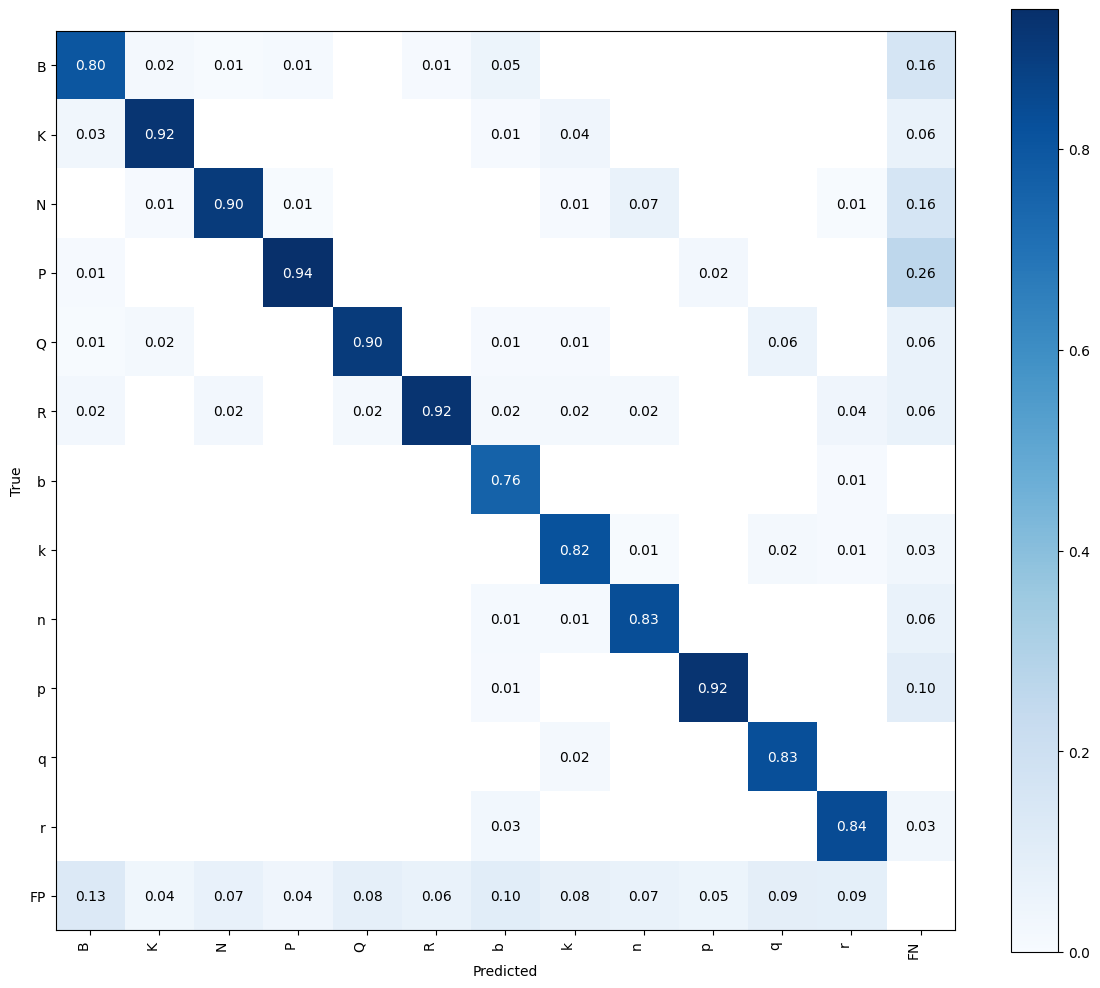

In [ ]:
dataset = sv.DetectionDataset.from_coco(
    images_directory_path=dataset_dir + '/test',
    annotations_path=annotation_dir
)

def callback(image):
    detections = model.predict(image, threshold=0.25) 
    return detections

confusion_matrix = sv.ConfusionMatrix.benchmark(
    dataset=dataset,
    callback=callback
)

confusion_matrix.plot(save_path=output_dir + '/confusion_matrix.png', normalize=True);

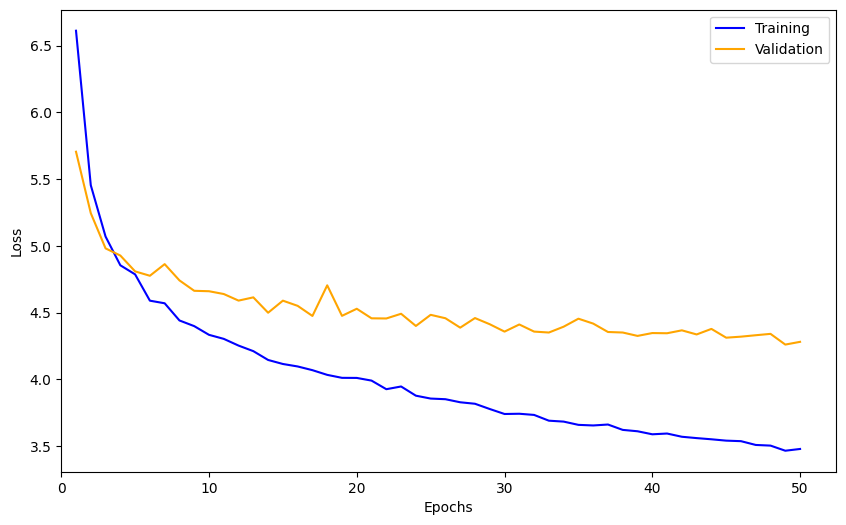

In [43]:
train_loss_path = output_dir + '/train_loss.csv'
val_loss_path = output_dir + '/val_loss.csv'
steps_per_epoch = 330

df_train = pd.read_csv(train_loss_path)
df_val = pd.read_csv(val_loss_path)
df_train['Epoch'] = df_train['Step'] / steps_per_epoch
df_val['Epoch'] = df_val['Step'] / steps_per_epoch

plt.figure(figsize=(10, 6))
plt.plot(
    df_train['Epoch'],
    df_train['Value'],
    label='Training',
    color='blue',
)
plt.plot(
    df_val['Epoch'],
    df_val['Value'],
    label='Validation',
    color='orange',
)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.xlim(left=0)
plt.savefig(output_dir + '/loss_plot.png', dpi=300, bbox_inches='tight')